# Experiment: Twisted Diffusion Sampler on MNIST

**Scope:**
In this notebook, we test the **Twisted Diffusion Sampler (TDS)**, a Sequential Monte Carlo (SMC) based approach for conditional sampling with diffusion models.

**Objective:**
Perform image restoration (Inpainting) on the **MNIST** dataset.

**Methodology:**
- **Model**: A pre-trained Denoising Diffusion Probabilistic Model (DDPM).
- **Task**: Reconstruct the center of an image that has been masked out.
- **Configuration**: We typically run the sampler with **$K=4$ particles**. This allows the algorithm to explore multiple potential restoration paths and weight them according to how well they match the observed data (the unmasked parts of the image), providing a more robust reconstruction than standard guidance methods.

## Importing the MNIST dataset and diffusion model

In [1]:
import warnings
warnings.filterwarnings('ignore')
from diffusers import DDPMPipeline
import torch
import numpy as np
from torchvision import transforms
from torchvision.datasets import MNIST

# --- 1. Load Model ---
print("Loading DDPM pipeline for MNIST/CIFAR-10...")
pipeline = DDPMPipeline.from_pretrained("dvgodoy/ddpm-cifar10-32-mnist")
model = pipeline.unet
scheduler = pipeline.scheduler

# Enable GPU if available (Fixed: removed CPU forcing)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

# --- 2. Prepare Data (MNIST) ---
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

# Download one image
dataset = MNIST(root='./data', train=True, download=True, transform=transform)
x_clean = dataset[0][0].unsqueeze(0).to(device) # Shape [1, 1, 32, 32]

# If the model expects 3 channels (common for models capable of CIFAR), we might need to repeat channels
if model.config.in_channels == 3:
    x_clean = x_clean.repeat(1, 3, 1, 1)

print(f"Input image shape: {x_clean.shape}")

Loading DDPM pipeline for MNIST/CIFAR-10...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch /home/onyxia/.cache/huggingface/hub/models--dvgodoy--ddpm-cifar10-32-mnist/snapshots/e2eb13c6ae24de41be4fbd24ef3b801f4a38a80e: Error no file named diffusion_pytorch_model.safetensors found in directory /home/onyxia/.cache/huggingface/hub/models--dvgodoy--ddpm-cifar10-32-mnist/snapshots/e2eb13c6ae24de41be4fbd24ef3b801f4a38a80e.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 12.02it/s]


Using device: cuda
Input image shape: torch.Size([1, 3, 32, 32])


## Twisted diffusion sampler

In [2]:
import torch
import torch.nn.functional as F

def twisted_diffusion_sampler(
    denoise_model,
    y_observed,
    TwistingFunction,
    T,
    K,
    sigma_sq,
    t_sigma_sq,
    scheduler=None # Added to access alphas/betas if needed
):
    """
    Generic TDS algorithm for conditional sampling with Dynamic Thresholding.
    """

    # Initialize K particles from the prior noise distribution
    x_T = torch.randn(K, *y_observed.shape[1:]).to(y_observed.device)

    # Initialize weights
    weights = torch.ones(K, device=y_observed.device) / K
    particles = x_T

    if scheduler:
        alphas = 1.0 - scheduler.betas.to(y_observed.device)
        alphas_cumprod = torch.cumprod(alphas, dim=0)

    timesteps = list(range(T))[::-1]

    for t in timesteps:
        t_tensor = torch.full((K,), t, device=y_observed.device, dtype=torch.long)

        # 1. Resample
        if t < T - 1:
            # Safety check for weights
            if torch.isnan(weights).any() or weights.sum() == 0:
                 weights = torch.ones_like(weights) / K
            indices = torch.multinomial(weights, K, replacement=True)
            particles = particles[indices]

        particles = particles.detach().requires_grad_(True)

        # 2. Denoise prediction
        model_output = denoise_model(particles, t_tensor).sample

        # Compute x_0_hat (estimated clean image) from epsilon
        alpha_bar_t = alphas_cumprod[t]
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)

        # Dynamic Thresholding: Clamp x_hat to [-1, 1] to prevent explosion
        # Added epsilon to denominator to avoid div by zero
        x_hat = (particles - sqrt_one_minus_alpha_bar_t * model_output) / (sqrt_alpha_bar_t + 1e-6)
        x_hat = x_hat.clamp(-1, 1)

        # 3. Calculate Twisting Function & Gradient
        log_p_tilde = TwistingFunction(x_hat, y_observed, t_sigma_sq[t])

        # 4. Conditional score approximation
        grad_log_p_tilde = torch.autograd.grad(outputs=log_p_tilde.sum(), inputs=particles)[0]

        beta_t = scheduler.betas[t].to(y_observed.device)
        alpha_t = alphas[t]

        pred_mean = (1 / torch.sqrt(alpha_t)) * (particles - (beta_t / sqrt_one_minus_alpha_bar_t) * model_output)

        # Add gradient guidance (shift)
        shift = beta_t * grad_log_p_tilde
        mu_twisted = pred_mean + shift

        # 5. Proposal Step
        noise = torch.randn_like(particles)
        if t > 0:
            particles = mu_twisted + torch.sqrt(beta_t) * noise
        else:
            particles = mu_twisted

        # 6. Update Weights
        with torch.no_grad():
            if t > 0:
                model_out_next = denoise_model(particles, torch.full((K,), t-1, device=y_observed.device, dtype=torch.long)).sample
                alpha_bar_prev = alphas_cumprod[t-1]

                x_hat_next = (particles - torch.sqrt(1 - alpha_bar_prev) * model_out_next) / (torch.sqrt(alpha_bar_prev) + 1e-6)
                x_hat_next = x_hat_next.clamp(-1, 1)

                new_log_weights = TwistingFunction(x_hat_next, y_observed, t_sigma_sq[t-1])
                weights = torch.softmax(new_log_weights, dim=0)

        particles = particles.detach()

    return particles, weights

## Creating a masked image

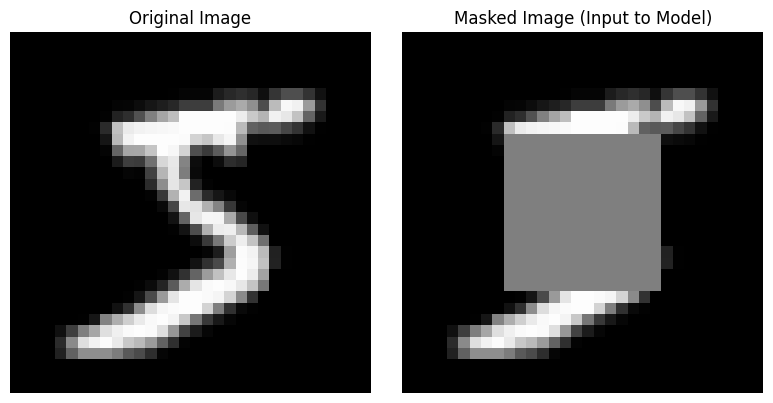

In [3]:
import torch
import matplotlib.pyplot as plt

# 1. Define Mask
def create_center_mask(image_shape, mask_size=12):
    """Creates a boolean mask where the center is blocked (False = unobserved)."""
    mask = torch.ones(image_shape)
    h, w = image_shape[-2:]
    cy, cx = h // 2, w // 2
    half = mask_size // 2
    mask[..., cy-half:cy+half, cx-half:cx+half] = 0
    return mask

# 2. Inpainting Twisting Function
def log_gaussian_twisting_function_inpainting(x_hat, y_observed, mask, variance):
    """
    Computes log p(y|x_hat) ~ N(y; x_hat * mask, variance).
    Effectively forces x_hat to match y where mask is 1.
    """
    # We only care about the error in the observed region (mask == 1)
    # y_observed should already be masked (0 in unobserved regions) or we multiply by mask
    diff = (y_observed - x_hat) * mask

    # Sum of squared errors
    sse = torch.sum(diff**2, dim=[1, 2, 3])
    return -0.5 * sse / variance

# 3. Visualization for Inpainting
def plot_inpainting_results(original, masked_input, restored_particles, weights, mask):
    best_idx = torch.argmax(weights).item()

    def to_numpy(t):
        img = t.squeeze().cpu().numpy()
        if img.ndim == 3: img = img.transpose(1, 2, 0)
        return (img + 1) / 2 # Scale [-1, 1] -> [0, 1]

    best_restored = to_numpy(restored_particles[best_idx])
    original_np = to_numpy(original)
    masked_np = to_numpy(masked_input)

    # Visual check: combine mask with restored to see fit
    # (In practice we just show the restored image)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original_np, cmap='gray' if original_np.ndim==2 else None)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(masked_np, cmap='gray' if masked_np.ndim==2 else None)
    axes[1].set_title("Masked Input (y)")
    axes[1].axis('off')

    axes[2].imshow(best_restored, cmap='gray' if best_restored.ndim==2 else None)
    axes[2].set_title("TDS Inpainted")
    axes[2].axis('off')
    plt.show()

# --- Visualize Mask Effect ---
# Create the mask
mask_example = create_center_mask(x_clean.shape, mask_size=14).to(device)
# Apply mask: observed part is x * mask
masked_image_example = x_clean * mask_example

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original
img_np = x_clean[0].permute(1, 2, 0).cpu().numpy()
img_np = (img_np + 1) / 2 # Normalize to [0, 1]
axes[0].imshow(img_np, cmap='gray' if img_np.shape[2]==1 else None)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Masked
masked_np = masked_image_example[0].permute(1, 2, 0).cpu().numpy()
masked_np = (masked_np + 1) / 2
axes[1].imshow(masked_np, cmap='gray' if masked_np.shape[2]==1 else None)
axes[1].set_title("Masked Image (Input to Model)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Testing the TDS

Running Twisted Diffusion Sampler for Inpainting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01676011..1.0091712].


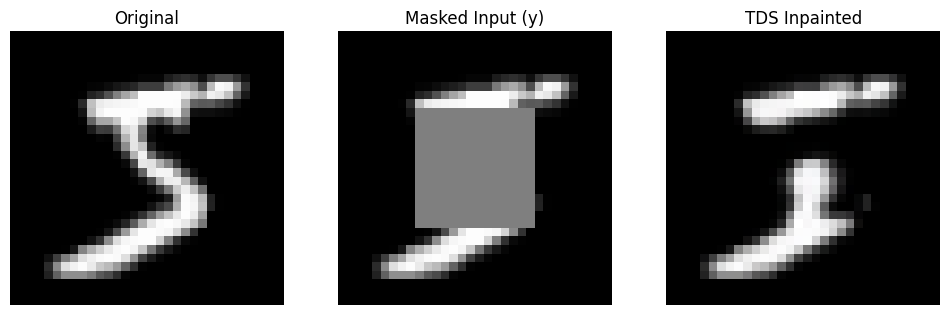

In [4]:
# --- Run Inpainting Experiment ---

# 1. Setup Data & Mask
mask = create_center_mask(x_clean.shape, mask_size=14).to(device)
y_masked = x_clean * mask # Observed image y

# 2. Setup Variance Schedule
alphas_cumprod = torch.cumprod(1 - scheduler.betas, dim=0).to(device)
t_sigma_sq = (1 - alphas_cumprod) * 0.5

print("Running Twisted Diffusion Sampler for Inpainting...")

# 3. Define Wrapper
# Clamp variance to avoid division by zero instability
twisting_wrapper_inpainting = lambda x, y, v: log_gaussian_twisting_function_inpainting(x, y, mask, max(v, 1e-5))

# 4. Run Sampler
restored_particles, weights = twisted_diffusion_sampler(
    denoise_model=model,
    y_observed=y_masked,
    TwistingFunction=twisting_wrapper_inpainting,
    T=1000,
    K=4,
    sigma_sq=None,
    t_sigma_sq=t_sigma_sq,
    scheduler=scheduler
)

# 5. Plot
plot_inpainting_results(x_clean, y_masked, restored_particles, weights, mask)